In [1]:
from google.colab import files
uploaded = files.upload()

Saving CC GENERAL.csv to CC GENERAL.csv


In [2]:
import pandas as pd

df = pd.read_csv("CC GENERAL.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### **EDA**

In [3]:
import pandas as pd

df = pd.read_csv("CC GENERAL.csv")

print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(8950, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  


### **DATA PREPARATION**

In [4]:
# Data Preparation

# 1. Drop customer ID (not useful for clustering)
df = df.drop("CUST_ID", axis=1)

# 2. Handle missing values
df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median(), inplace=True)
df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median(), inplace=True)

# 3. Check that no missing values remain
print(df.isnull().sum())

# 4. Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df)

print("Data preparation completed. Shape of scaled data:", X.shape)

/tmp/ipykernel_232/2135122435.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median(), inplace=True)
/tmp/ipykernel_232/2135122435.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64
Data preparation completed. Shape of scaled data: (8950, 17)


### **Apply DBSCAN**

In [5]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.2, min_samples=5, metric="euclidean")

labels = dbscan.fit_predict(X)

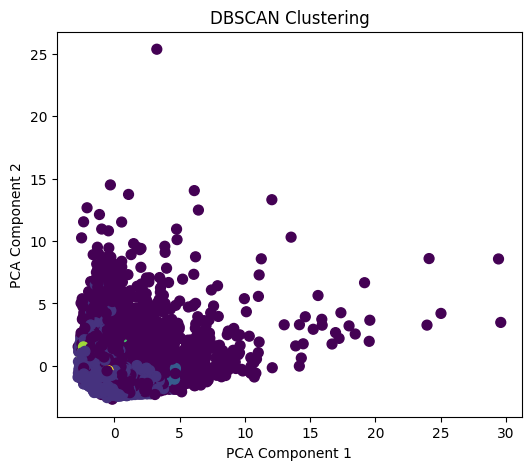

In [6]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=50)
plt.title("DBSCAN Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [7]:
import numpy as np

print("Cluster labels:", np.unique(labels))
print("Number of clusters (excluding noise):", len(set(labels)) - (1 if -1 in labels else 0))
print("Number of noise points:", list(labels).count(-1))

Cluster labels: [-1  0  1  2  3  4  5  6]
Number of clusters (excluding noise): 7
Number of noise points: 2165


In [9]:
from sklearn.metrics import silhouette_score

mask = labels != -1
score = silhouette_score(X[mask], labels[mask])

print("Silhouette Score:", score)

Silhouette Score: -0.19691743333634334


The clustering quality was evaluated using the silhouette score. The score obtained was about -0.20, which indicates that the clusters are not well separated and may overlap. This suggests that DBSCAN did not perform very well on this dataset with the chosen parameters. This can happen because the CC GENERAL dataset contains many features and customer behaviors that are not clearly separated into dense groups.

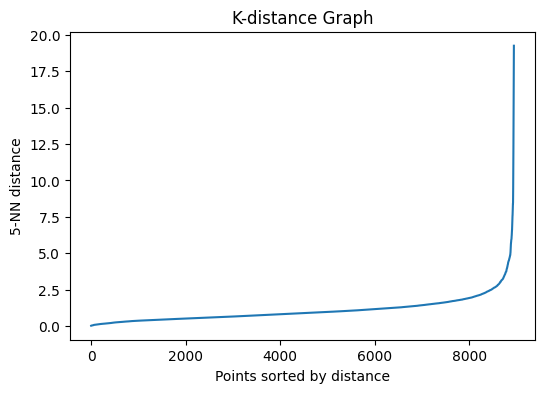

In [10]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Use 5 neighbors (same as min_samples)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X)

distances, indices = neighbors_fit.kneighbors(X)

# Sort distances
distances = np.sort(distances[:,4])

plt.figure(figsize=(6,4))
plt.plot(distances)
plt.title("K-distance Graph")
plt.xlabel("Points sorted by distance")
plt.ylabel("5-NN distance")
plt.show()

In [11]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2, min_samples=5)
labels = dbscan.fit_predict(X)

In [12]:
from sklearn.metrics import silhouette_score
import numpy as np

mask = labels != -1

if len(np.unique(labels[mask])) > 1:
    score = silhouette_score(X[mask], labels[mask])
    print("Silhouette Score (excluding noise):", score)
else:
    print("Not enough clusters to compute silhouette score")

Silhouette Score (excluding noise): 0.4459701008515353


 The clustering quality was evaluated using the silhouette score. The score obtained now after choosing better ep value was about 0.45, which indicates a reasonable level of separation between clusters. This means that DBSCAN was able to identify meaningful groups of customers while also detecting some noise points. The result suggests that customers can be segmented into clusters based on similar spending and payment behavior, although some overlap still exists because real customer behavior is naturally diverse.